In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from saidownscale import downscaling_utils, run_bcsd

In [2]:
from saidownscale.downscaling_utils import interpolate_fine_to_coarse_grid

# 0. Get data

In [3]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "tas",
}

In [4]:
dict_all = run_bcsd.get_all_data(
    gcm=RUN_PARAMETERS["gcm"], var_name=RUN_PARAMETERS["var_name"], verbose=True
)

Loaded data: 1.11 seconds
Subset time: 0.00 seconds


In [5]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_2817/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_2817/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


### Subset data to demo region (South Africa)

In [6]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds
lon_min = lon_min - 2
lon_max = lon_max + 2
lat_min = lat_min - 2
lat_max = lat_max + 2

In [7]:
for key in dict_all:
    dict_all[key] = downscaling_utils.subset_space(
        dict_all[key], coord_bounds_list=[lat_min, lat_max, lon_min, lon_max]
    )

# 1. Preprocess data

In [8]:
RECHUNK_WORKFLOW = True  # flag: whether to rechunk data depending on the step
VERBOSE = True

In [9]:
dict_all = run_bcsd.preprocess_data(
    dict_all,
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
)

Rechunked obs to full space: 5.31 seconds
Interpolated obs to coarse grid: 59.27 seconds
Detrended data: 13.48 seconds


# 2. Bias correct with quantile mapping

In [11]:
dict_all = run_bcsd.bias_correct(
    dict_all=dict_all,
    var_name=RUN_PARAMETERS["var_name"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    do_windowing=True,
)

  0%|          | 0/620 [00:00<?, ?it/s]/opt/coiled/env/lib/python3.13/site-packages/ibicus/debias/_debiaser.py:387: UserWarning: Debiaser runs without time-information for at least one of obs, cm_hist or cm_future.
                        This information is inferred, assuming the first observation is on a January 1st. Observations are chunked according to the assumed time information.
                        This might lead to slight numerical differences to the run with time information, however the debiasing is not fundamentally changed.
  return func(obs, cm_hist, cm_future, **kwargs)
100%|██████████| 620/620 [02:08<00:00,  4.83it/s]


Quantile mapped historical: 128.87 seconds


100%|██████████| 620/620 [03:00<00:00,  3.44it/s]

Quantile mapped future: 180.41 seconds
Added back trend: 0.02 seconds


# 3. Downscale

In [12]:
dict_all = run_bcsd.spatially_disaggregate(
    dict_all=dict_all, verbose=VERBOSE, rechunk_workflow=RECHUNK_WORKFLOW, clim_method="fft"
)

Rechunked all to full time: 0.53 seconds
Downscaled historical: 8.18 seconds
Downscaled future: 10.37 seconds


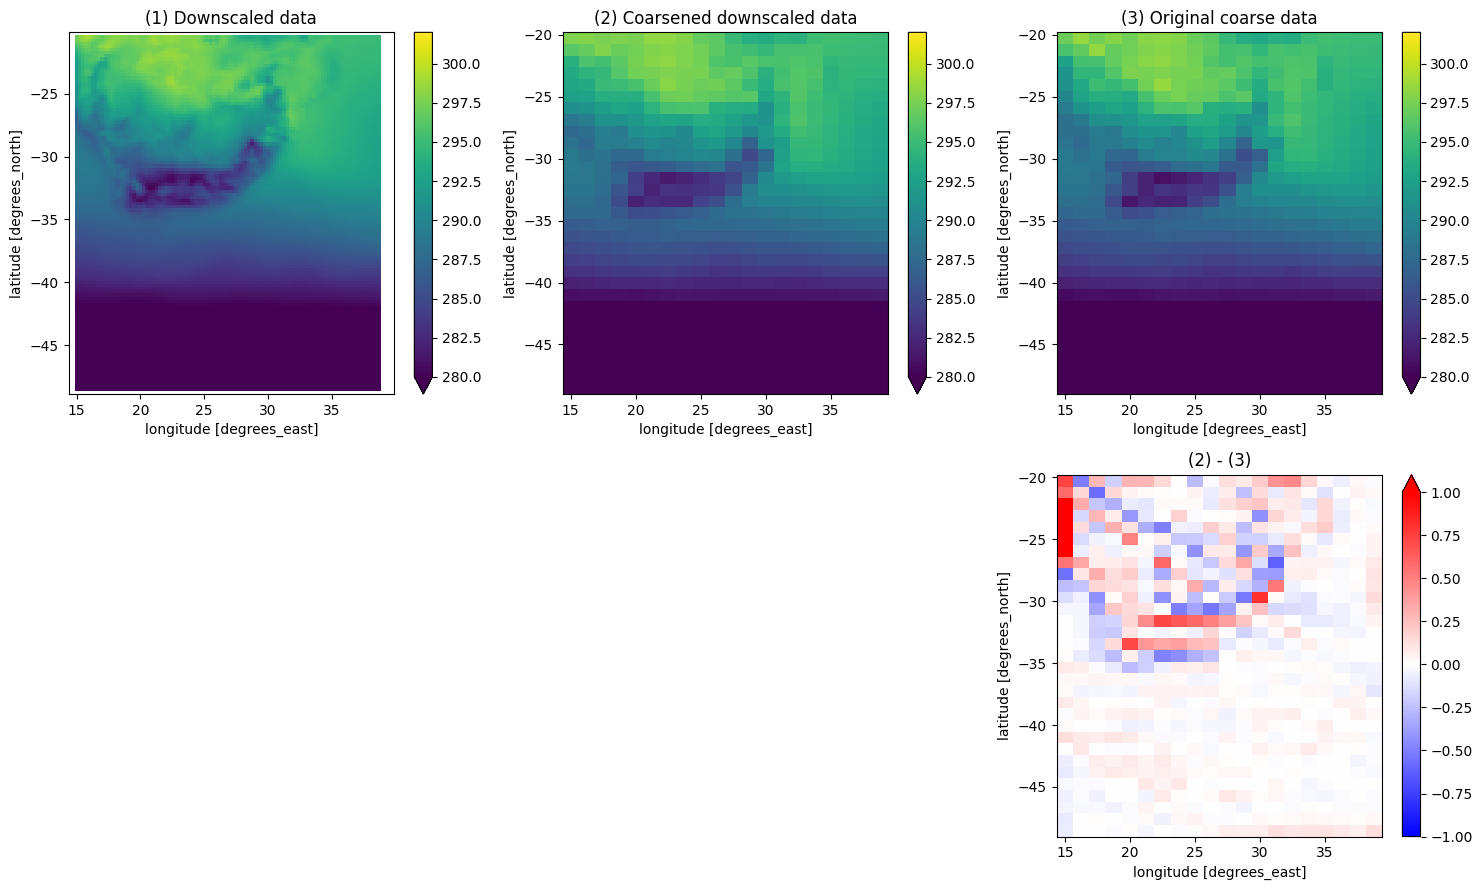

In [16]:
# Single day in the time series
t = 1000
fine_t_mean = (
    dict_all["model_hist_debiased_downscaled"][t, :, :].drop_vars("time", errors="ignore").compute()
)
coarse_t_mean = (
    dict_all["model_hist_debiased"][t, :, :].drop_vars("time", errors="ignore").compute()
)
v1_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=fine_t_mean, da_coarse_grid=coarse_t_mean
)

plt.figure(figsize=(15, 9))
plt.subplot(2, 3, 1)
fine_t_mean.plot(vmin=280, vmax=302)
plt.title("(1) Downscaled data")
plt.subplot(2, 3, 2)
v1_coarse.plot(vmin=280, vmax=302)
plt.title("(2) Coarsened downscaled data")
plt.subplot(2, 3, 3)
coarse_t_mean.plot(vmin=280, vmax=302)
plt.title("(3) Original coarse data")

plt.subplot(2, 3, 6)
(v1_coarse - coarse_t_mean).plot(vmax=1, vmin=-1, cmap=plt.cm.bwr)
plt.title("(2) - (3)")
plt.tight_layout()

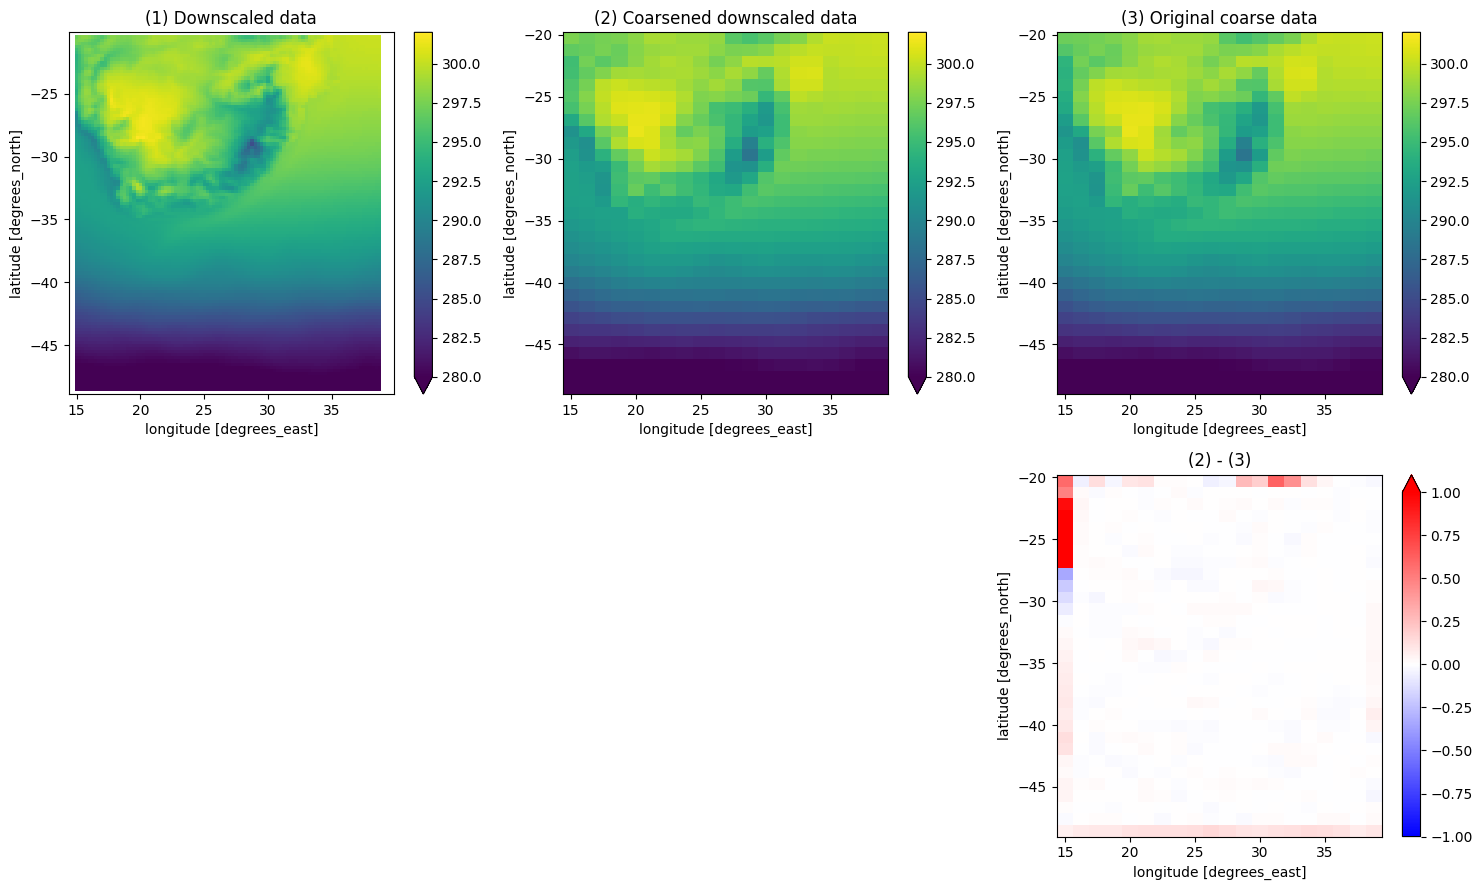

In [17]:
# Monthly average

m = 1
fine_month_mean = (
    dict_all["model_hist_debiased_downscaled"]
    .where(dict_all["model_hist_debiased_downscaled"]["time.month"] == m)
    .mean(dim="time")
    .compute()
)
coarse_month_mean = (
    dict_all["model_hist_debiased"]
    .where(dict_all["model_hist_debiased"]["time.month"] == m)
    .mean(dim="time")
    .compute()
)
v1_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=fine_month_mean, da_coarse_grid=coarse_month_mean
)

plt.figure(figsize=(15, 9))
plt.subplot(2, 3, 1)
fine_month_mean.plot(vmin=280, vmax=302)
plt.title("(1) Downscaled data")
plt.subplot(2, 3, 2)
v1_coarse.plot(vmin=280, vmax=302)
plt.title("(2) Coarsened downscaled data")
plt.subplot(2, 3, 3)
coarse_month_mean.plot(vmin=280, vmax=302)
plt.title("(3) Original coarse data")

plt.subplot(2, 3, 6)
(v1_coarse - coarse_month_mean).plot(vmax=1, vmin=-1, cmap=plt.cm.bwr)
plt.title("(2) - (3)")
plt.tight_layout()

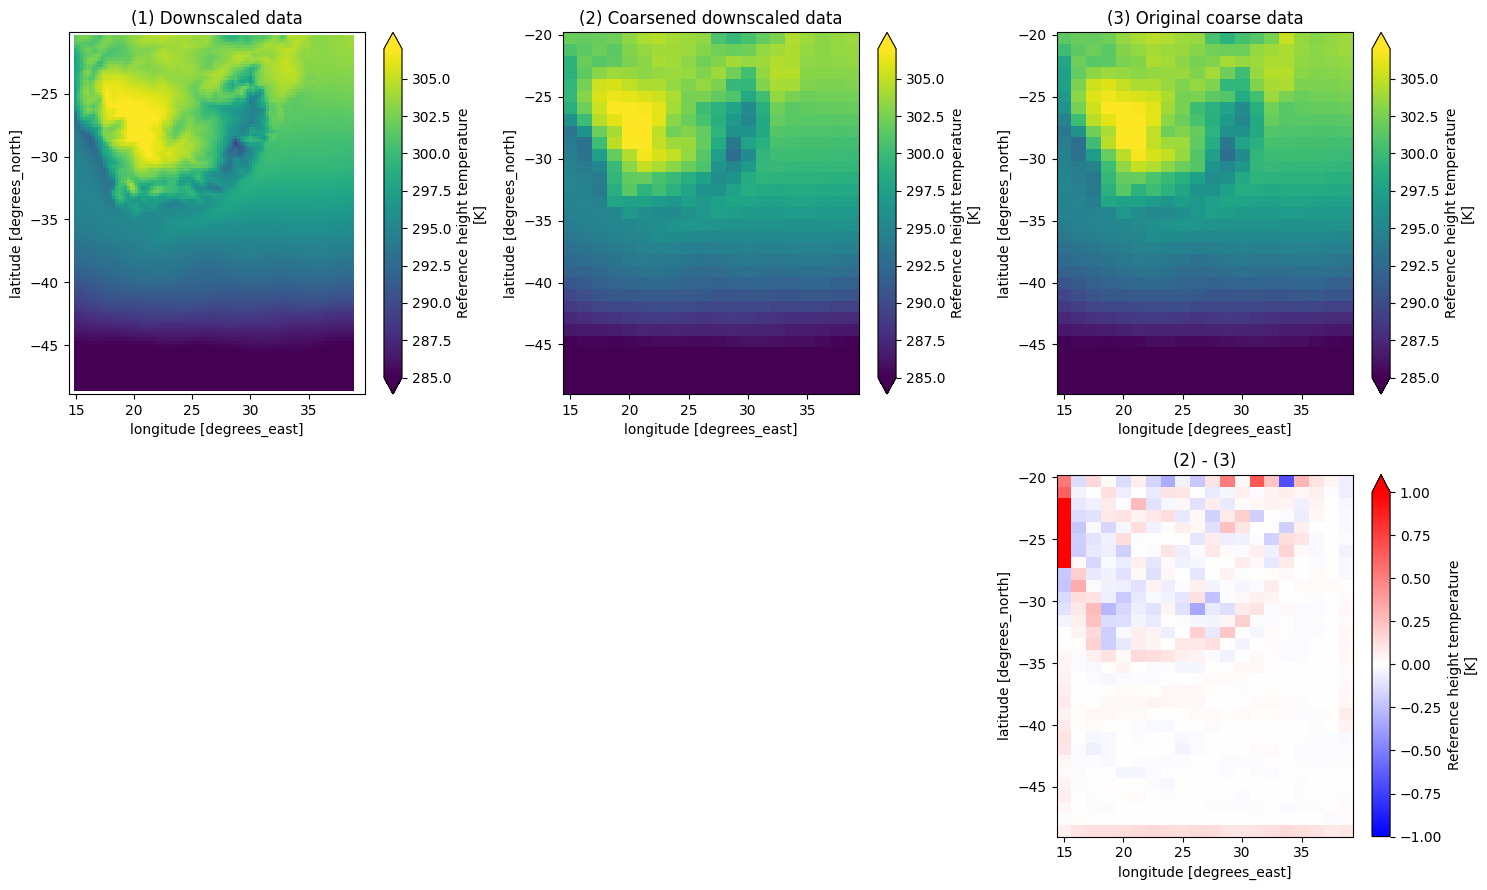

In [27]:
# Monthly average

m = 1
fine_month_mean = (
    dict_all["scenario_debiased_downscaled"]
    .where(dict_all["scenario_debiased_downscaled"]["time.month"] == m)
    .mean(dim="time")
    .compute()
).drop_vars("ensemble_member")
coarse_month_mean = (
    dict_all["scenario_debiased"]
    .where(dict_all["scenario_debiased"]["time.month"] == m)
    .mean(dim="time")
    .compute()
).drop_vars("ensemble_member")
v1_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=fine_month_mean, da_coarse_grid=coarse_month_mean
)

plt.figure(figsize=(15, 9))
plt.subplot(2, 3, 1)
fine_month_mean.plot(vmin=285, vmax=307)
plt.title("(1) Downscaled data")
plt.subplot(2, 3, 2)
v1_coarse.plot(vmin=285, vmax=307)
plt.title("(2) Coarsened downscaled data")
plt.subplot(2, 3, 3)
coarse_month_mean.plot(vmin=285, vmax=307)
plt.title("(3) Original coarse data")

plt.subplot(2, 3, 6)
(v1_coarse - coarse_month_mean).plot(vmax=1, vmin=-1, cmap=plt.cm.bwr)
plt.title("(2) - (3)")
plt.tight_layout()

# Look at results at Cape Town, South Africa

In [28]:
dict_all_CT = {}
for key, ds in dict_all.items():
    print(key)
    ds_CT = ds.sel(lat=cape_town_y, lon=cape_town_x, method="nearest").compute()
    dict_all_CT[key] = ds_CT

model_hist
obs
model_scenario
obs_coarse
historical_scenario
scenario_detrended
scenario_trend
model_hist_debiased
scenario_debiased_detrended
scenario_debiased
model_hist_debiased_downscaled
scenario_debiased_downscaled


In [29]:
dict_all_CT["model_scenario_debiased"] = dict_all_CT["scenario_debiased"]
dict_all_CT["model_scenario_debiased_downscaled"] = dict_all_CT["scenario_debiased_downscaled"]

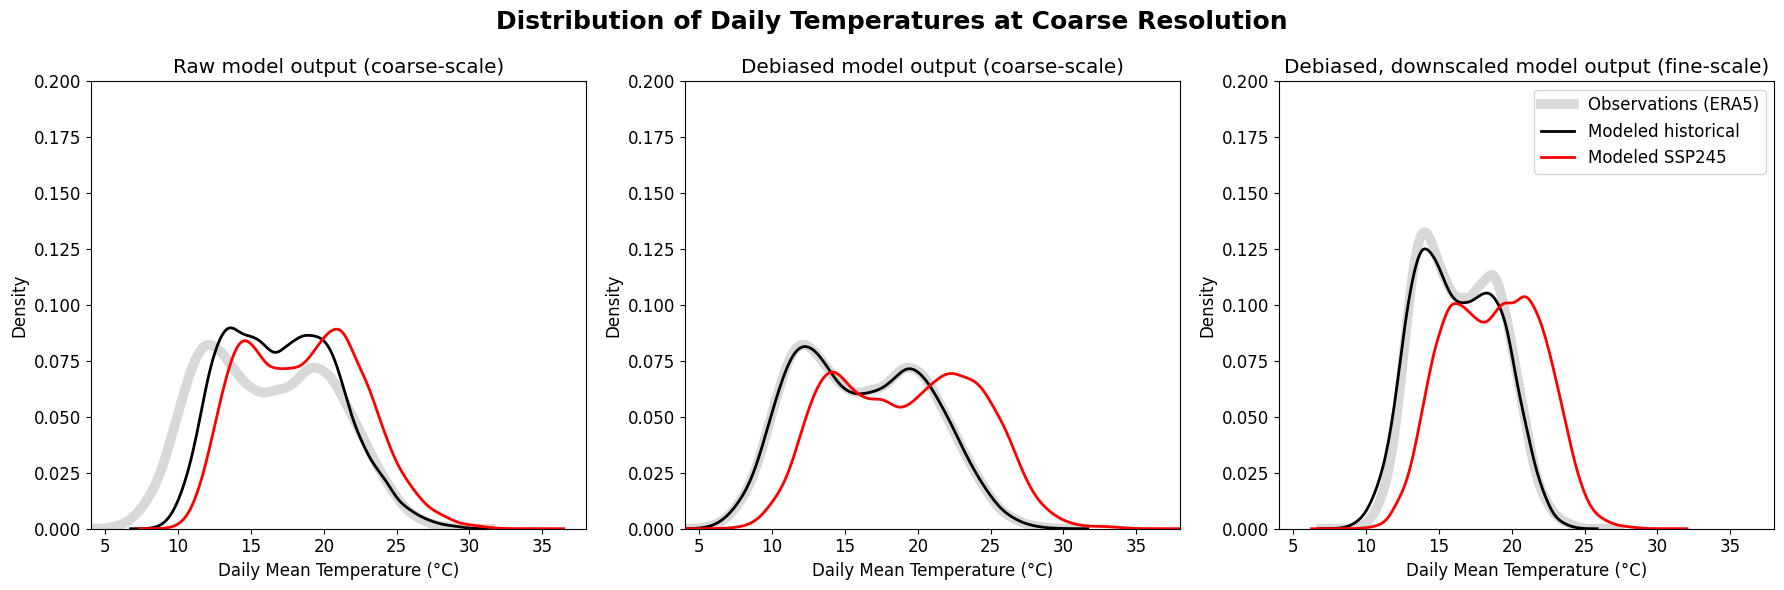

In [31]:
colors = ["black", "red"]
labels = ["Modeled historical", "Modeled SSP245"]
dataset_keys = ["model_hist", "model_scenario"]

plt.rcParams["font.size"] = 12


def format_subplot(res="coarse"):
    if res == "coarse":
        sns.kdeplot(
            dict_all_CT["obs_coarse"].as_numpy() - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    elif res == "fine":
        sns.kdeplot(
            dict_all_CT["obs"] - 273.15,
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    plt.ylim([0, 0.2])
    plt.xlim([4, 38])
    plt.xlabel("Daily Mean Temperature (°C)")


plt.figure(figsize=(18, 6))
plt.subplot(1, 3, 1)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Raw model output (coarse-scale)")


plt.subplot(1, 3, 2)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased model output (coarse-scale)")


plt.subplot(1, 3, 3)
format_subplot(res="fine")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased_downscaled"] - 273.15,
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
    )
plt.title("Debiased, downscaled model output (fine-scale)")

plt.suptitle(
    "Distribution of Daily Temperatures at Coarse Resolution",
    fontsize=18,
    fontweight="bold",
)
plt.tight_layout()
plt.legend(fontsize=12)